In [21]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import dRSA, load_img_natraster, print_wise, TimeSeries, get_lagplot_subset
from general_utils.dRSA import across_areas_dRSA
from general_utils.II import dynInformationImbalance

In [4]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    new_fs: int = 100 # Hz
    monkey_name = "three0"
    date = "250313"
    brain_area = "AIT"
    RDM_metric_A: str = 'cosine_cnt'
    RDM_metric_B: str = 'cosine_cnt'
    
    k: int = 1
cfg = Cfg()


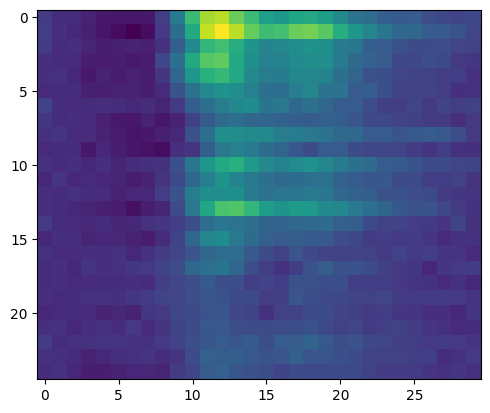

In [14]:
raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, brain_area=cfg.brain_area, new_fs=cfg.new_fs)
plt.imshow(np.mean(raster.get_array(), axis=2))

In [17]:
drsa_obj = dRSA(cfg.RDM_metric_A)
drsa_obj.compute_both_RDM_timeseries(raster, raster)

In [19]:
drsa_mat= drsa_obj.compute_dRSA()

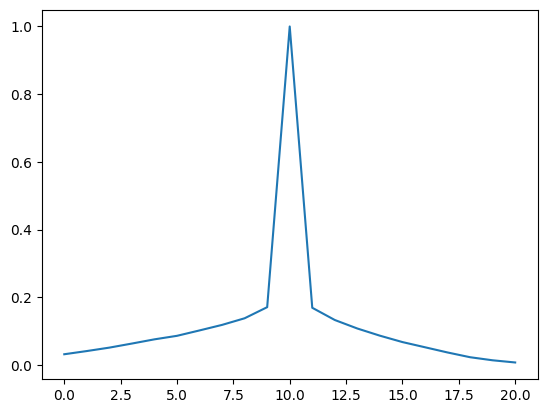

In [26]:
# plt.imshow(drsa_mat)
plt.plot(get_lagplot_subset(drsa_mat, np.arange(10, 25), max_lag=10))